# Lab 0 - Unified sklearn and PyTorch
Clean notebook: only essential setup and actionable TODOs.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_digits
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

## TODO sklearn
1. Load the tabular dataset with `fetch_openml`.
2. Clean data, apply encoding, train/test split, and scaling.
3. Train at least 3 sklearn models and compare metrics and confusion matrix.

In [8]:
# TODO: implement the sklearn pipeline here

def load_data(dataset_name='titanic'):
    # Load the Titanic dataset
    X, y = fetch_openml(dataset_name, version=1, as_frame=True, parser='auto', return_X_y=True)
    return X, y.astype(int)

X, y = load_data()

In [9]:
print("\n\nX.info():")
X.info()
print("\n\ny.info():")
y.info()



X.info():
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   str     
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   str     
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    str     
 9   embarked   1307 non-null   category
 10  boat       486 non-null    str     
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    str     
dtypes: category(2), float64(3), int64(3), str(5)
memory usage: 115.2 KB


y.info():
<class 'pandas.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: survived
Non-Null Count  Dtype
--------------  -----
1309 non-null   int64
dtypes: int64(1)
memory usage: 10.4 KB


In [10]:
def split_data(X, y, test_size=0.2, random_state=42, stratify=None):
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=stratify)

X_train, X_test, y_train, y_test = split_data(X, y, stratify=y)

In [11]:
def clean_data(X_train, y_train, X_test, y_test):
    # Remove duplicates
    X_train = X_train.drop_duplicates()
    y_train = y_train[X_train.index]
    X_test = X_test.drop_duplicates()
    y_test = y_test[X_test.index]
    
    # Remove duplicate columns
    X_train = X_train.T.drop_duplicates().T
    y_train = y_train[X_train.index]
    X_test = X_test.T.drop_duplicates().T
    y_test = y_test[X_test.index]

    # Remove columns with the same value in all rows
    nunique = X_train.nunique()
    cols_to_drop = nunique[nunique == 1].index
    X_train = X_train.drop(columns=cols_to_drop)
    y_train = y_train[X_train.index]
    X_test = X_test.drop(columns=cols_to_drop)
    y_test = y_test[X_test.index]

    # Check which columns have missing and NaN values
    missing_cols = X_train.columns[X_train.isnull().any()]
    if 'age' in missing_cols:
        X_train['age'] = X_train['age'].fillna(X_train['age'].mean())
        X_test['age'] = X_test['age'].fillna(X_train['age'].mean())
    if 'fare' in missing_cols:
        X_train['fare'] = X_train['fare'].fillna(X_train['fare'].median())
        X_test['fare'] = X_test['fare'].fillna(X_train['fare'].median())
    if 'embarked' in missing_cols:
        X_train['embarked'] = X_train['embarked'].fillna(X_train['embarked'].mode()[0])
        X_test['embarked'] = X_test['embarked'].fillna(X_train['embarked'].mode()[0])

    # Drop useless columns
    X_train = X_train.drop(columns=['name', 'ticket', 'cabin', 'home.dest', 'boat', 'body'])
    y_train = y_train[X_train.index]
    X_test = X_test.drop(columns=['name', 'ticket', 'cabin', 'home.dest', 'boat', 'body'])
    y_test = y_test[X_test.index]

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = clean_data(X_train, y_train, X_test, y_test)

In [ ]:
def preprocess_data(X_train, y_train, X_test, y_test):
    # Compute categorical and numerical columns
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
    numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

    ct = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

    X_train = ct.fit_transform(X_train)
    X_test = ct.transform(X_test)

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = preprocess_data(X_train, y_train, X_test, y_test)

PCA reduced dimensionality to 178 features




Decision Tree:
Best parameters: {'max_depth': 5, 'min_samples_split': 5}
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       162
           1       0.66      0.63      0.64       100

    accuracy                           0.73       262
   macro avg       0.72      0.71      0.71       262
weighted avg       0.73      0.73      0.73       262



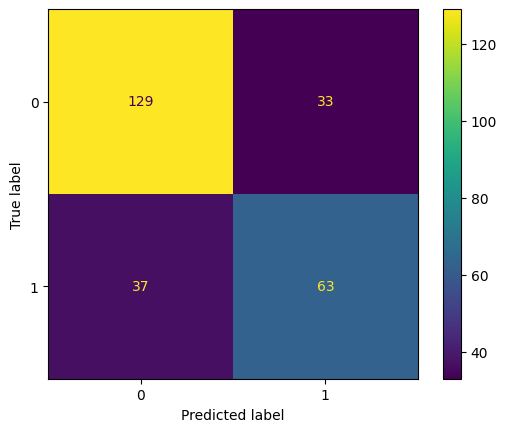



Random Forest:
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       162
           1       0.78      0.60      0.68       100

    accuracy                           0.78       262
   macro avg       0.78      0.75      0.76       262
weighted avg       0.78      0.78      0.78       262



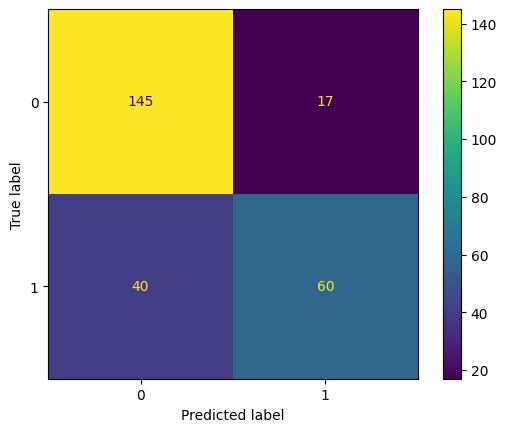



Logistic Regression:
Best parameters: {'C': 1}
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       162
           1       0.79      0.71      0.75       100

    accuracy                           0.82       262
   macro avg       0.81      0.80      0.80       262
weighted avg       0.82      0.82      0.81       262



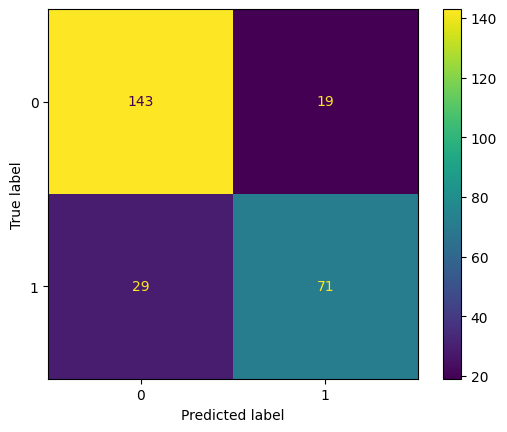

In [13]:
def training(X_train, y_train, X_test, y_test):
    def evaluate_model(model, X_test, y_test):
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred))
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
        plt.show()
    
    def grid_search(model, param_grid, X_train, y_train):
        from sklearn.model_selection import GridSearchCV
        grid_search = GridSearchCV(model, param_grid, cv=5)
        grid_search.fit(X_train, y_train)
        print("Best parameters:", grid_search.best_params_)
        return grid_search.best_estimator_
    
    results = {}
    
    print("\n\nDecision Tree:")
    dt = grid_search(DecisionTreeClassifier(random_state=42), {
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }, X_train, y_train)
    evaluate_model(dt, X_test, y_test)
    results['Decision Tree'] = dt

    print("\n\nRandom Forest:")
    rf = grid_search(RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }, X_train, y_train)
    evaluate_model(rf, X_test, y_test)
    results['Random Forest'] = rf

    print("\n\nLogistic Regression:")
    lr = grid_search(LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.01, 0.1, 1, 10, 100]
    }, X_train, y_train)
    evaluate_model(lr, X_test, y_test)
    results['Logistic Regression'] = lr

    return results

models = training(X_train, y_train, X_test, y_test)

## TODO PyTorch
1. Load `load_digits` and normalize features.
2. Build train/test DataLoaders.
3. Define an MLP, training loop, and final evaluation.

In [14]:
# TODO: implement dataset pipeline + PyTorch model + training here
def load_dataset(dataset_name='digits'):
    if dataset_name == 'digits':
        data = load_digits()
        X, y = data.data, data.target
    else:
        raise ValueError(f"Dataset {dataset_name} not supported")
    return X, y

X, y = load_dataset()

## TODO final comparison
1. Compare sklearn vs PyTorch performance.
2. Report observations on runtime, accuracy, and stability.